# Лабораторная работа 5

Тема: **Регуляризация и нормализация в нейросетях (L2, Dropout, BatchNorm)**  
Цель: на одной и той же задаче (MNIST в PyTorch) изучить, как разные приёмы регуляризации влияют на переобучение и качество обобщения, и сформулировать **свои** выводы по результатам экспериментов.

> Этот ноутбук — заготовка под вашу работу, а не готовый отчёт.  
> Если вы попытаетесь автоматически заполнить его текст генеративной моделью, это проявится в стиле, обобщённости формулировок и несоответствии коду/графикам.
> Оценка ставится за:
> - осмысленный код (который вы можете объяснить),
> - честно проведённые эксперименты,
> - ваши собственные формулировки наблюдений и выводов.

## 1. Ваше предварительное представление о регуляризации

Перед тем как трогать PyTorch, сформулируйте для себя:

1. Что вы называете «переобучением» в контексте нейросетей (на своём языке, без академических определений).  
2. Почему, на ваш взгляд, регуляризация и нормализация могут помочь, если уже и так «всё обучается»?  
3. В чём принципиальная разница между:
   - L2‑штрафом на веса (weight decay),
   - Dropout,
   - BatchNorm — если объяснять их одногруппнику за 2–3 минуты.

Напишите ответы в следующей ячейке. Здесь важен ваш голос, а не повторение чужого текста — не бойтесь неровных формулировок, главное, чтобы они были **вашими**.

In [ ]:
pre_intro = """ЗДЕСЬ НАПИШИТЕ СВОИ ПРЕДВАРИТЕЛЬНЫЕ ПРЕДСТАВЛЕНИЯ О ПЕРЕОБУЧЕНИИ
И РЕГУЛЯРИЗАЦИИ. Можно в виде пунктов или одного цельного текста.
Старайтесь не звучать как учебник, а описать то, что вы реально думаете.

1. Переобучением можно назвать то состояние, когда нейросеть буквально воспринимает все примеры. Она не ищет закономерностей и подстраивается под обучающие данные слишком точно.
В этом случае нейросеть будет "угадывать" какой же ответ будет правильным, а не "думать".
 
2. Даже при условии, что "все обучается", регуляризация и нормализация помогают модели не переобучиться. Регуляризация ограничивает сложность модели, позволяя корректно работать с новыми данными.
Нормализация приводит данные к одному масштабу. Таким образом модель будет "думать", обобщая данные и ища закономерности.

3. L2-штраф, Dropout и BatchNorm - это все методы используемые для ограничения риска переобучения, однако они имеют разный функционал.
L2-штраф возводит в квадрат веса и добавляет штраф к функции потерь. Чем больше изначальный вес, тем больше его квадрат и тем больше будет итоговый штраф для всех весов.
Dropout случайно отключает часть нейронов, чтобы они не слишком подстраивались под данные.
BatchNorm нормализует данные на каждом слое, делая их распределение стабильным."""
print(pre_intro)

ЗДЕСЬ НАПИШИТЕ СВОИ ПРЕДВАРИТЕЛЬНЫЕ ПРЕДСТАВЛЕНИЯ О ПЕРЕОБУЧЕНИИ
И РЕГУЛЯРИЗАЦИИ. Можно в виде пунктов или одного цельного текста.
Старайтесь не звучать как учебник, а описать то, что вы реально думаете.

1. Переобучением можно назвать то состояние, когда нейросеть буквально воспринимает все примеры. Она не ищет закономерностей и подстраивается под обучающие данные слишком точно.
В этом случае нейросеть будет "угадывать" какой же ответ будет правильным, а не "думать".
 
2. Даже при условии, что "все обучается", регуляризация и нормализация помогают модели не переобучиться. Регуляризация ограничивает сложность модели, позволяя корректно работать с новыми данными.
Нормализация приводит данные к одному масштабу. Таким образом модель будет "думать", обобщая данные и ища закономерности.

3. L2-штраф, Dropout и BatchNorm - это все методы используемые для ограничения риска переобучения, однако они имеют разный функционал.
L2-штраф возводит в квадрат веса и добавляет штраф к функции потерь. Че

## 2. Импорт и настройка среды

Сделайте стандартную подготовку:
- импортируйте PyTorch, torchvision и необходимые утилиты;
- зафиксируйте **один** seed (свой, не «магический» 42), чтобы эксперименты можно было воспроизвести;
- определите, есть ли CUDA, но пишите код так, чтобы и на CPU всё работало.


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ SEED (запишите его потом в отчёте)
MY_SEED = 0
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 0


## 3. Данные MNIST и базовая предобработка

Вы уже работали с MNIST в ЛР4, так что здесь не должно быть сюрпризов.  
Задача на этом шаге:
- загрузить train/test;
- применить `ToTensor` и нормализацию (можно стандартную для MNIST);
- выбрать размер батча так, чтобы обучение шло достаточно быстро, но не превращалось в «шум».  

Важно: число `batch_size`, нормализацию и все прочие решения потом нужно будет **объяснить** в отчёте, а не «так было в шаблоне».

In [27]:
batch_size = 256  #TODO: Попробуйте несколько значений. Запишите, как меняется время эпохи и шумность loss-кривой в зависимости от размера батча

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

train size = 60000
test size  = 10000
batch_size = 256


Быстро посмотрим на несколько картинок, чтобы убедиться, что всё загружается и отображается как ожидается.


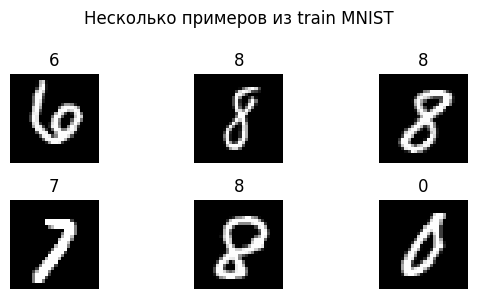

In [4]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

### Ваши короткие наблюдения по данным

Ответьте здесь буквально в 3–5 предложениях:
- насколько «чистыми» и различимыми кажутся цифры;
- есть ли такие изображения, которые уже сейчас вы бы сами классифицировали с сомнением.

Не пытайтесь «угадывать правильный ответ» — это просто ваши наблюдения.

In [37]:
data_impression = """ЗДЕСЬ ВКРАТЦЕ ОПИШИТЕ, КАК ВАМ ВЫГЛЯДЯТ ДАННЫЕ.
Можно упомянуть пары цифр, которые визуально похожи (например, 4 и 9).

Цифры кажутся довольно чистыми и многие различимы. Есть пары цифр, которые похожи, например, 0 и 6, 2 и 8, 4 и 9 (это я реально увидел, а не с примера выше списал)"""
print(data_impression)

ЗДЕСЬ ВКРАТЦЕ ОПИШИТЕ, КАК ВАМ ВЫГЛЯДЯТ ДАННЫЕ.
Можно упомянуть пары цифр, которые визуально похожи (например, 4 и 9).

Цифры кажутся довольно чистыми и многие различимы. Есть пары цифр, которые похожи, например, 0 и 6, 2 и 8, 4 и 9 (это я реально увидел, а не с примера выше списал)


## 4. Три варианта модели

Мы будем сравнивать три архитектурных варианта на одной и той же задаче:

1. **BaseMLP** — без регуляризации (кроме implicit нормализации входа).  
2. **DropoutMLP** — тот же каркас, но с Dropout в скрытых слоях.  
3. **BatchNormMLP** — тот же каркас, но со слоями BatchNorm1d.

L2‑регуляризацию (weight_decay) будем добавлять через оптимизатор к любому из вариантов.

Архитектуру берите не слишком маленькую (чтобы сеть могла переобучиться), но и не чрезмерную.


In [34]:
class BaseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            # TODO: размеры слоёв (256, 128) выбраны произвольно.
            # Подберите свои значения и обоснуйте в отчёте:
            # достаточно ли этого, чтобы модель вообще могла переобучиться?
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class DropoutMLP(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: Dropout стоит ПОСЛЕ активации, это стандартная практика.
        # Попробуйте поставить его ДО активации и опишите, изменилось ли что-то.
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 1024),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, что физически происходит здесь во время train? ОТВЕТ: Здесь Dropout отключает отдельные нейроны на каждом слое с вероятностью p
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, почему здесь тот же p, а не другой? ОТВЕТ: Для упрощения настройки модели и экспериментов. Достаточно подобрать один гиперпараметр на всю модель.
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: BatchNorm1d стоит ДО активации — это один из двух стандартных вариантов.
        # Попробуйте переставить его после ReLU. Есть ли разница в сходимости?
        # TODO: объясните в отчёте: что именно нормализует BatchNorm1d(256)?
        # Что такое «батч» в данном контексте, строки или столбцы матрицы?
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(BaseMLP())
print(DropoutMLP())
print(BatchNormMLP())

BaseMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
DropoutMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=512, out_features=10, bias=True)
  )
)
BatchNormMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (

В отчёте вы потом отдельно опишете:
- какие именно размеры слоёв и значения Dropout использовали;
- пробовали ли другие варианты (и чем они закончились).

## 5. Общие функции обучения и оценки

Чтобы не копировать код, напишем универсальные функции:
- `train_one_epoch` — один проход по train;
- `evaluate` — оценка на любом DataLoader.

Если вы хотите добавить дополнительные метрики/логирование — делайте это здесь и прокомментируйте в отчёте.


In [6]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Функция запуска эксперимента для одной конфигурации

Чтобы аккуратно сравнивать разные варианты (без регуляризации, с L2, с Dropout, с BatchNorm), удобно иметь одну функцию `run_experiment`, которая:
- создаёт модель;
- настраивает оптимизатор (с нужным `weight_decay` и `lr`);
- обучает модель `num_epochs` эпох;
- возвращает историю `loss/accuracy`.

Важный момент: вы сами выбираете числа эпох, шаг обучения и значения L2/Dropout, но потом должны будете указать их в отчёте и прокомментировать.


In [7]:
def run_experiment(model_class, config_name,
                   weight_decay=0.0, dropout_p=0.5,
                   num_epochs=8, lr=1e-3):
    print("\n=== Конфигурация:", config_name, "===")

    # создаём модель нужного класса
    if model_class is DropoutMLP:
        model = model_class(p=dropout_p).to(device)
    else:
        model = model_class().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return model, history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор экспериментов (пример)

Рекомендуется провести, как минимум, такие эксперименты:

1. `Base / no_reg` — BaseMLP, `weight_decay=0`.  
2. `Base / L2` — BaseMLP, `weight_decay` (например, `1e-4` или `1e-3`).  
3. `Dropout p=0.5` — DropoutMLP, без L2 для чистоты.  
4. `BatchNorm` — BatchNormMLP, без L2 для начала.  

При желании можно добавить комбинации (BatchNorm + L2, Dropout + L2), но важно успеть осмысленно проанализировать хотя бы базовые варианты.


In [ ]:
# 1. Базовая модель без регуляризации
base_model, base_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / no_reg",
    weight_decay=0.0,
    num_epochs=12,
    lr=1e-3
)


=== Конфигурация: Base / no_reg ===
Эпоха 1/8 | train_loss=0.2767, train_acc=0.9205, test_loss=0.1195, test_acc=0.9648
Эпоха 2/8 | train_loss=0.0986, train_acc=0.9693, test_loss=0.0963, test_acc=0.9693
Эпоха 3/8 | train_loss=0.0617, train_acc=0.9805, test_loss=0.0713, test_acc=0.9783
Эпоха 4/8 | train_loss=0.0429, train_acc=0.9860, test_loss=0.0689, test_acc=0.9785
Эпоха 5/8 | train_loss=0.0325, train_acc=0.9898, test_loss=0.0713, test_acc=0.9770
Эпоха 6/8 | train_loss=0.0266, train_acc=0.9909, test_loss=0.0722, test_acc=0.9787
Эпоха 7/8 | train_loss=0.0244, train_acc=0.9919, test_loss=0.0719, test_acc=0.9798
Эпоха 8/8 | train_loss=0.0170, train_acc=0.9943, test_loss=0.0783, test_acc=0.9790


In [41]:
# 2. Базовая модель с L2 (weight decay)
# TODO: weight_decay=1e-4 — почему именно это значение?
# Попробуйте 1e-2 и 1e-6. Запишите test_acc для каждого случая и опишите, где слишком много L2.

# ОТВЕТ: 1. 1е-2 - 0.9649
#        2. 1e-6 - 0.9812
# Слишком много L2 в первом случае. Модель сильно недообучается. 1e-4 как золотая середина, есть исследования на разных датасетах, которые это доказали.
l2_model, l2_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / L2 (wd=1e-4)",
    weight_decay=1e-4,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Base / L2 (wd=1e-4) ===
Эпоха 1/8 | train_loss=0.2767, train_acc=0.9191, test_loss=0.1224, test_acc=0.9617
Эпоха 2/8 | train_loss=0.0995, train_acc=0.9699, test_loss=0.0845, test_acc=0.9733
Эпоха 3/8 | train_loss=0.0669, train_acc=0.9786, test_loss=0.0740, test_acc=0.9770
Эпоха 4/8 | train_loss=0.0491, train_acc=0.9846, test_loss=0.0716, test_acc=0.9768
Эпоха 5/8 | train_loss=0.0346, train_acc=0.9887, test_loss=0.0741, test_acc=0.9793
Эпоха 6/8 | train_loss=0.0283, train_acc=0.9905, test_loss=0.0742, test_acc=0.9768
Эпоха 7/8 | train_loss=0.0249, train_acc=0.9919, test_loss=0.0702, test_acc=0.9791
Эпоха 8/8 | train_loss=0.0224, train_acc=0.9925, test_loss=0.0708, test_acc=0.9784


In [ ]:
# 3. Модель с Dropout
# TODO: dropout_p=0.5 — агрессивное значение. Попробуйте p=0.2 и p=0.7.
# При каком p модель обучается слишком медленно, а при каком почти не регуляризует?

# ОТВЕТ: На 0.2 скорость обучения высокая, но почти не регуляризует. На 0.7 медленнее, но регуляризация работает лучше (возможно даже слишком лучше, мешая обучению).
drop_model, drop_hist = run_experiment(
    model_class=DropoutMLP,
    config_name="Dropout p=0.7",
    dropout_p=0.2,
    weight_decay=0.0,
    num_epochs=10,
    lr=1e-3
)


=== Конфигурация: Dropout p=0.7 ===


KeyboardInterrupt: 

In [ ]:
# 4. Модель с BatchNorm
bn_model, bn_hist = run_experiment(
    model_class=BatchNormMLP,
    config_name="BatchNorm",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: BatchNorm ===
Эпоха 1/8 | train_loss=0.1836, train_acc=0.9435, test_loss=0.0973, test_acc=0.9705
Эпоха 2/8 | train_loss=0.0960, train_acc=0.9697, test_loss=0.0817, test_acc=0.9745
Эпоха 3/8 | train_loss=0.0711, train_acc=0.9768, test_loss=0.0862, test_acc=0.9778
Эпоха 4/8 | train_loss=0.0569, train_acc=0.9815, test_loss=0.1142, test_acc=0.9742
Эпоха 5/8 | train_loss=0.0510, train_acc=0.9832, test_loss=0.0900, test_acc=0.9797
Эпоха 6/8 | train_loss=0.0400, train_acc=0.9862, test_loss=0.1233, test_acc=0.9771
Эпоха 7/8 | train_loss=0.0353, train_acc=0.9885, test_loss=0.1396, test_acc=0.9789
Эпоха 8/8 | train_loss=0.0321, train_acc=0.9896, test_loss=0.1323, test_acc=0.9772


## 8. Визуальное сравнение кривых

Теперь важно не просто посмотреть на финальные числа, а **сравнить динамику** обучения для разных вариантов: 
как меняются train/test loss и accuracy по эпохам.

Сделаем один общий график для всех конфигураций.


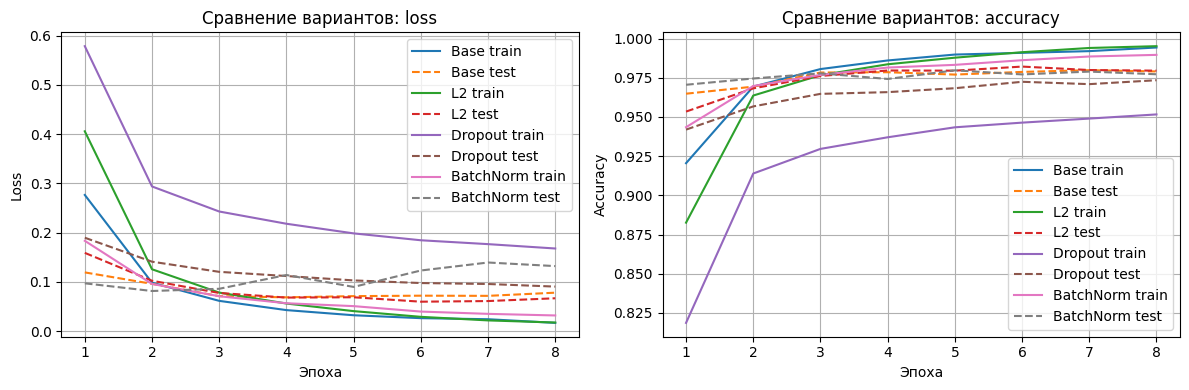

In [31]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(
    histories=[base_hist, l2_hist, drop_hist, bn_hist],
    labels=["Base", "L2", "Dropout", "BatchNorm"],
    title_prefix="Сравнение вариантов: "
)

## 9. Ваш разбор результатов

Теперь самая важная (и самая «анти‑генеративная») часть: **живой разбор** того, что вы увидели на графиках и в числах.

Постарайтесь ответить (в свободной форме, без маркированного списка):

- Как вёл себя разрыв между train и test для базовой модели? Было ли заметное переобучение уже к 8‑й эпохе?  
- Что дало добавление L2: стало ли train хуже, а test лучше/стабильнее?  
- Как ведёт себя Dropout: не «ломает» ли он обучение в начале, не делает ли train слишком шумным?  
- Что меняет BatchNorm: меняется ли скорость выхода на насыщение по точности, становятся ли кривые «ровнее»?  
- Если нужно было выбрать **одну** технику регуляризации для этой задачи, что бы вы выбрали и почему (с опорой на ваши конкретные графики и числа)?

Не стесняйтесь упоминать неудачные настройки (слишком большой weight_decay, странный Dropout и т.п.) — это тоже часть обучения.


In [ ]:
analysis_comment = """ЗДЕСЬ НАПИШИТЕ РАЗВЁРНУТЫЙ КОММЕНТАРИЙ К ГРАФИКАМ И ЧИСЛАМ.
Ссылайтесь на конкретные значения (например, test accuracy для Base и L2) и
опишите, как выглядят кривые. Не бойтесь писать «по‑человечески».
Ценность текста в том, чтобы через несколько месяцев вы сами вспомнили ход
экспериментов и свои выводы.

Выбрал модель с количеством нейронов (1024 - 512 - 256 - 10). Тесты показали, что уже и изначальный вариант (256 - 128 - 64 - 10) имел небольшие задатки переобучения, но я сделал побольше, чтобы наверняка.
Поставив Dropout до и BatchNorm после активации на обе функции показали признаки переобучения, когда test loss начал расти, а train loss падал. Особенно это заметно на тестовой линии BatchNorm.
Batch_size = 1024 показал время эпохи примерно 13 секунд. 256 - =13 секунд. 64 - ~20 секунд. На батче 64 отчетливо заметны признаки переобучения (train loss падает, test loss растет). Признаки есть и на 1024, и на 256, но не такие заметные. Проверял на базовом MLP. В итоге оставил 256 (считаю более эстетичным вариантом)
С добавлением L2 обучение стало лучше, loss
C BatchNorm линии не становятся ровнее, наоборот у меня это самая сломанная кривая.
Если нужно было бы вабрать одну технику регуляризации, то я бы не выбрал BatchNorm (по крайней мере на данном этапе обучения). Из двух оставшихся выбрал бы L2, потому что он стал для меня самым понятным методом из всех, и точность по итогу с ним получилась выше всего (0.9812). Это очень удобно: быстро растешь? - ШТРАФ.
А Dropout для меня пока как самый-самый агрессивный вариант: добавляешь множество признаков, а потом половину отсеиваешь просто потому что признаков много. Зачем тогда много признаков?
"""
print(analysis_comment)

ЗДЕСЬ НАПИШИТЕ РАЗВЁРНУТЫЙ КОММЕНТАРИЙ К ГРАФИКАМ И ЧИСЛАМ.
Ссылайтесь на конкретные значения (например, test accuracy для Base и L2) и
опишите, как выглядят кривые. Не бойтесь писать «по‑человечески».
Ценность текста в том, чтобы через несколько месяцев вы сами вспомнили ход
экспериментов и свои выводы.


## 10. Итоговое резюме по лабораторной работе

В конце сформулируйте короткое резюме (5–8 предложений):

- Какие **конкретные** настройки (архитектура, lr, weight_decay, Dropout‑p, число эпох) вы в итоге считаете для этой задачи «золотой серединой» и почему.  
- Чем ваши ожидания по эффекту регуляризации совпали / не совпали с тем, что вы реально увидели.  
- Как вы теперь объяснили бы одногруппнику, когда есть смысл использовать L2, когда Dropout, а когда BatchNorm — именно на примере **ваших** экспериментов, а не абстрактной теории.


In [ ]:
final_summary = """ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РЕЗЮМЕ.
Сделайте акцент на том, что вы унесёте из этой работы дальше: какие настройки и
приёмы будете пробовать в следующих задачах и почему.

Я считаю, что самыми оптимальными настройками для этой задачи станут L2-штраф с weight_decay=1e-4, Dropout с p=0,5 и число эпох = 6.
Такое количество эпох, потому что при тестировании я не заметил ни разу, чтобы были прямо явные отклонения после 6 эпохи, всё можно понять уже на 5-ой.
Было странно увидеть такой странный loss у тестового BatchNorm, он слишком выделяется на фоне остальных.
И думал, что L2-штраф наоборот всегда будет мешать обучению, но на деле оказалось, что это мой фаворит.
В целом ожидания от регуляризации оправдались, сложно было по началу считывать эти кривые на графиках, но я справился.

Если бы я объяснял одногруппнику, то не порекомендовал бы ему BatchNorm (основываясь на своем опыте в этой лабе), Dropout когда много нейронов в модели и нужно их отсеять, а L2-штраф можно всегда, если заметно переобучение."""
print(final_summary)

ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РЕЗЮМЕ.
Сделайте акцент на том, что вы унесёте из этой работы дальше: какие настройки и
приёмы будете пробовать в следующих задачах и почему.
